In [6]:
import csv
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv(r'C:\Users\hbbel\OneDrive\Desktop\Research\Git Repos\Principle-Elicitation\data analysis\data\elicitation_data_full.csv')

In [8]:

for key in df.keys():
    print(key)

StartDate
EndDate
Status
IPAddress
Progress
Duration (in seconds)
Finished
RecordedDate
ResponseId
RecipientLastName
RecipientFirstName
RecipientEmail
ExternalReference
LocationLatitude
LocationLongitude
DistributionChannel
UserLanguage
Q_RecaptchaScore
Consent_Q
Prolific_ID
con_b_personal
con_b_pers_elab
con_b_govern
con_b_govern_elab
con_b_matrix_1
con_b_matrix_2
con_b_matrix_3
partDemo.age
partDemo.gender
partDemo.gender_7_TEXT
partDemo.ethnicity
partDemo.ethnicity_7_TEXT
partDemo.education
con_a_personal
con_a_pers_elab
con_a_gov
con_a_gov_elab
con_a_matrix_1
con_a_matrix_2
con_a_matrix_3
2_Principle Q1_1
2_Principle Q1_2
2_Principle Q2_1
2_Principle Q2_2
2_Principle Q2_3
2_Principle Q2_4
2_Principle Q2_5
2_Principle Q2_6
2_Principle Q2_7
3_Principle Q1_1
3_Principle Q1_2
3_Principle Q2_1
3_Principle Q2_2
3_Principle Q2_3
3_Principle Q2_4
3_Principle Q2_5
3_Principle Q2_6
3_Principle Q2_7
4_Principle Q1_1
4_Principle Q1_2
4_Principle Q2_1
4_Principle Q2_2
4_Principle Q2_3
4_Princip

In [9]:
# Split the data into constitution and principle conditions

# Add a bool feature to filter out only Prolific submissions
df['PID_Correct_Len'] = df['PROLIFIC_PID'].str.len() ==  24


dfs = {group_name: group for group_name, group in df.groupby('Version')}

const_df = dfs['Constitution']

princ_df = dfs['Principle']

# pare down the irrelevant fields

const_fields = ['con_b_personal','con_b_pers_elab','con_b_govern','con_b_govern_elab','con_b_matrix_1',
                'con_b_matrix_2','con_b_matrix_3','con_a_personal','con_a_pers_elab','con_a_gov','con_a_gov_elab',
                'con_a_matrix_1','con_a_matrix_2','con_a_matrix_3', 'partDemo.age',	'partDemo.gender',
             	'partDemo.gender_7_TEXT', 'partDemo.ethnicity',	'partDemo.ethnicity_7_TEXT', 'partDemo.education',
                'PROLIFIC_PID', 'Const_Order', 'PID_Correct_Len'
]


const_df = const_df[const_fields]


princ_fields = ['partDemo.age',	'partDemo.gender', 'partDemo.gender_7_TEXT', 'partDemo.ethnicity', 'partDemo.ethnicity_7_TEXT', 
                'partDemo.education', 'PROLIFIC_PID', '2_Principle Q1_1','2_Principle Q1_2','2_Principle Q2_1','2_Principle Q2_2',
                '2_Principle Q2_3','2_Principle Q2_4','2_Principle Q2_5','2_Principle Q2_6','2_Principle Q2_7','3_Principle Q1_1',
                '3_Principle Q1_2','3_Principle Q2_1','3_Principle Q2_2','3_Principle Q2_3','3_Principle Q2_4','3_Principle Q2_5',
                '3_Principle Q2_6','3_Principle Q2_7','4_Principle Q1_1','4_Principle Q1_2','4_Principle Q2_1','4_Principle Q2_2',
                '4_Principle Q2_3','4_Principle Q2_4','4_Principle Q2_5','4_Principle Q2_6','4_Principle Q2_7','5_Principle Q1_1',
                '5_Principle Q1_2','5_Principle Q2_1','5_Principle Q2_2','5_Principle Q2_3','5_Principle Q2_4','5_Principle Q2_5',
                '5_Principle Q2_6','5_Principle Q2_7','6_Principle Q1_1','6_Principle Q1_2','6_Principle Q2_1','6_Principle Q2_2',
                '6_Principle Q2_3','6_Principle Q2_4','6_Principle Q2_5','6_Principle Q2_6','6_Principle Q2_7','7_Principle Q1_1',
                '7_Principle Q1_2','7_Principle Q2_1','7_Principle Q2_2','7_Principle Q2_3','7_Principle Q2_4','7_Principle Q2_5',
                '7_Principle Q2_6','7_Principle Q2_7','attention_check_1_1','attention_check_1_2','attention_check_2_1',
                'attention_check_2_2','attention_check_2_3','attention_check_2_4','attention_check_2_5','attention_check_2_6',
                'attention_check_2_7','PID_Correct_Len'

]
princ_df = princ_df[princ_fields]



In [10]:
# Drop data with wrong length PIDs (Should remove most of our testing data, but double check)

const_df = const_df[const_df['PID_Correct_Len'] == True]

princ_df = princ_df[princ_df['PID_Correct_Len'] == True]

In [11]:
# Now just focus on the constitution condition


# const_df.fillna(value = 0, inplace=True)

# Specify the rating columns
const_ratings = ['con_b_personal','con_b_govern','con_b_matrix_1',
                'con_b_matrix_2','con_b_matrix_3','con_a_personal','con_a_gov',
                'con_a_matrix_1','con_a_matrix_2','con_a_matrix_3']

# Convert all the ratings to int
const_df[const_ratings] = const_df[const_ratings].astype(float)



# First we'll drop any 'unsure' answers


const_df = const_df[const_df[const_ratings] != 6]






In [12]:
personal_pref_cols = ['con_b_personal', 'con_a_personal']
govern_pref_cols = ['con_b_govern', 'con_a_gov']

moral_grounding_cols = ['con_a_matrix_1', 'con_b_matrix_1']
consensus_cols = ['con_a_matrix_2', 'con_b_matrix_2']
coherence_cols = ['con_a_matrix_3', 'con_b_matrix_3']

In [13]:
#Build new columns that merge the scores from each condition

const_df['coherence'] = const_df['con_a_matrix_3'].fillna(const_df['con_b_matrix_3'])

const_df['consensus'] = const_df[consensus_cols[0]].fillna(const_df[consensus_cols[1]])

const_df['moral_grounding'] = const_df[moral_grounding_cols[0]].fillna(const_df[moral_grounding_cols[1]])

const_df['govern_pref'] = const_df[govern_pref_cols[0]].fillna(const_df[govern_pref_cols[1]])

const_df['personal_pref'] = const_df[personal_pref_cols[0]].fillna(const_df[personal_pref_cols[1]])


2      3.0
4      5.0
6      5.0
7      5.0
10     3.0
11     5.0
13     3.0
14     4.0
15     5.0
17     2.0
18     2.0
20     3.0
24     2.0
27     3.0
28     2.0
31     3.0
34     3.0
35     4.0
38     NaN
40     4.0
42     5.0
43     5.0
44     3.0
51     4.0
52     2.0
54     3.0
56     4.0
58     2.0
62     5.0
63     4.0
64     3.0
65     2.0
67     4.0
70     5.0
72     4.0
74     4.0
75     2.0
76     4.0
79     5.0
81     3.0
82     3.0
84     5.0
85     3.0
86     4.0
90     3.0
92     4.0
93     1.0
97     4.0
98     1.0
99     3.0
101    3.0
103    4.0
Name: consensus, dtype: float64


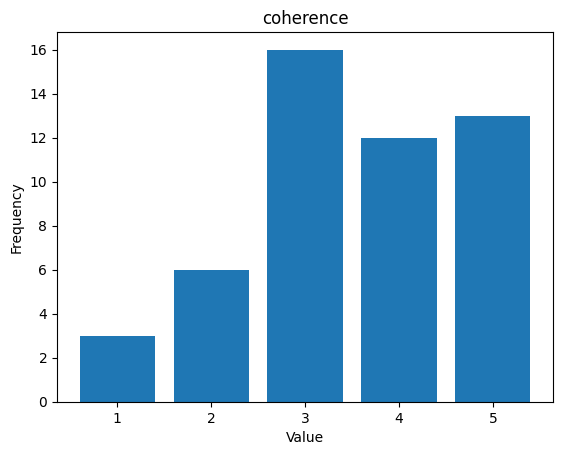

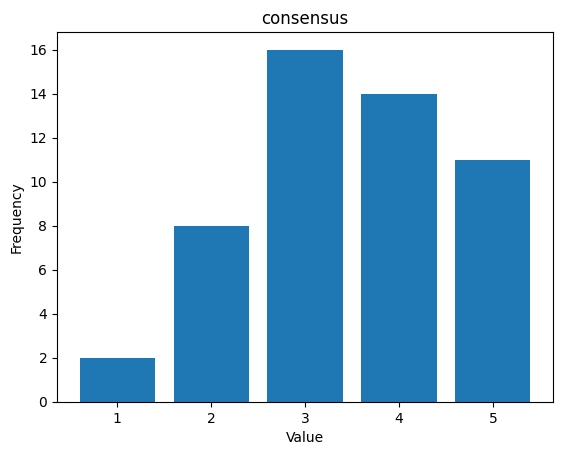

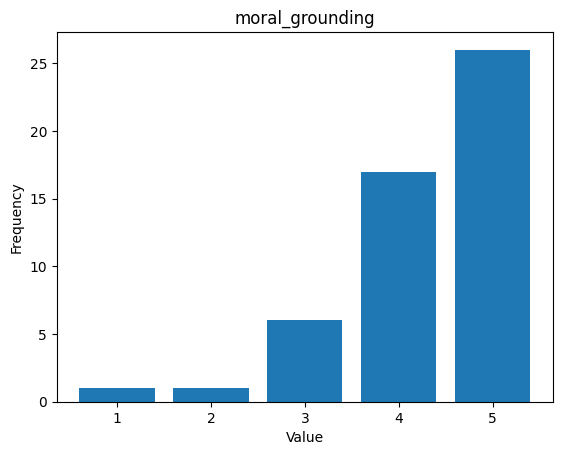

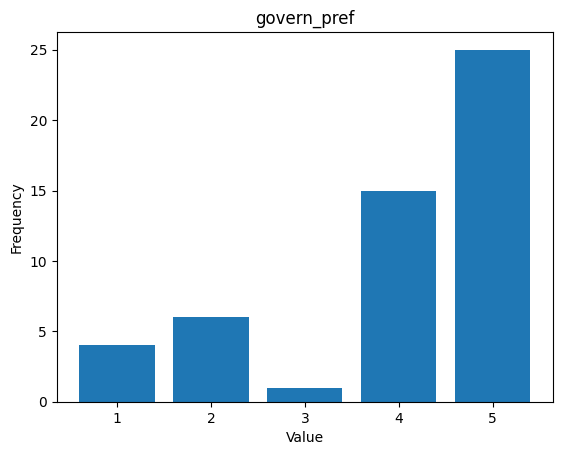

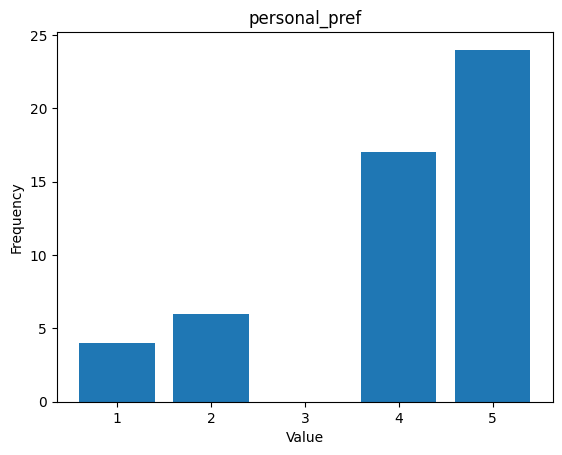

In [14]:
# Plot distributions for each measure
import matplotlib.pyplot as plt


print(const_df['consensus'])

analysis_fields = ['coherence', 'consensus', 'moral_grounding', 'govern_pref', 'personal_pref']

for item in analysis_fields:

    bins = np.arange(1,7) - 0.5 # Define explicit bins to ensure consistent width/alignment
    plt.xticks(np.arange(1, 6))

    plt.hist(const_df[item], bins=bins, rwidth=0.8)

    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(item)
    plt.show()



In [21]:
# Count our constitution winrate (4 or 5) vs ICAI (1 or 2)



for item in analysis_fields:


    loss_mask = const_df[item].isin([1, 2])
    loss_count = loss_mask.sum().sum()

    tie_mask = const_df[item].isin([3])
    tie_count = tie_mask.sum().sum()

    win_mask = const_df[item].isin([4, 5])
    win_count = win_mask.sum().sum()

    print(f'{item} winrate: {(win_count / (win_count + loss_count)):.2g}  ({tie_count} ties) ({win_count} wins) ({loss_count} losses)')
    
    


coherence winrate: 0.74  (16 ties) (25 wins) (9 losses)
consensus winrate: 0.71  (16 ties) (25 wins) (10 losses)
moral_grounding winrate: 0.96  (6 ties) (43 wins) (2 losses)
govern_pref winrate: 0.8  (1 ties) (40 wins) (10 losses)
personal_pref winrate: 0.8  (0 ties) (41 wins) (10 losses)
